In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import geopandas as gpd
import statsmodels.formula.api as smf
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Data lives in data/, figures save to output/
DATA_DIR = '/Users/jacksonsharpe/QSS20_Final_Project_Sharpe/data'
OUTPUT_DIR = '/Users/jacksonsharpe/QSS20_Final_Project_Sharpe/output'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.chdir(DATA_DIR)
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Data directory: /Users/jacksonsharpe/QSS20_Final_Project_Sharpe/data
Output directory: /Users/jacksonsharpe/QSS20_Final_Project_Sharpe/output


In [2]:
# Load merged country-year dataset
country_year = pd.read_csv('merged_attitudes_policy.csv')

# Load individual-level merged data
def load_ess_merged(ess_path='ESSQSS20.csv', merged_path='merged_attitudes_policy.csv'):
    """Load and merge individual ESS data with policy panel for analysis."""
    cols = [
        'cntry', 'essround', 'imbgeco', 'imueclt', 'imwbcnt',
        'brncntr', 'eisced', 'eduyrs', 'agea', 'gndr',
        'uempla', 'lrscale', 'stfeco'
    ]
    ess = pd.read_csv(ess_path, usecols=cols)
    for col in ['imbgeco', 'imueclt', 'imwbcnt']:
        ess[col] = ess[col].where(ess[col] <= 10)
    ess = ess[ess['brncntr'] == 1].copy()
    ess['immig_attitude'] = ess[['imbgeco', 'imueclt', 'imwbcnt']].mean(axis=1)
    ess = ess.dropna(subset=['immig_attitude'])
    ess['stfeco'] = ess['stfeco'].where(ess['stfeco'] <= 10)
    ess['agea'] = ess['agea'].where(ess['agea'] <= 120)
    ess['eduyrs'] = ess['eduyrs'].where(ess['eduyrs'] <= 30)
    round_to_year = {
        1:2002, 2:2004, 3:2006, 4:2008, 5:2010,
        6:2012, 7:2014, 8:2016, 9:2018, 10:2020
    }
    ess['year'] = ess['essround'].map(round_to_year)
    ess = ess.dropna(subset=['year'])
    ess['year'] = ess['year'].astype(int)
    ess['econ_dissatisfied'] = (ess['stfeco'] <= 4).astype(int)
    policy = pd.read_csv(merged_path)[['cntry', 'year', 'net_restrict_score', 'net_major_score', 'net_nonmajor_score']]
    merged = pd.merge(ess, policy, on=['cntry', 'year'], how='inner')
    return merged

ess_merged = load_ess_merged()
print(f"Individual-level merged data: {ess_merged.shape}")

# Country code to full name mapping
cntry_to_name = {
    'AT':'Austria','BE':'Belgium','BG':'Bulgaria','HR':'Croatia','CY':'Cyprus',
    'CZ':'Czechia','DK':'Denmark','EE':'Estonia','FI':'Finland','FR':'France',
    'DE':'Germany','GR':'Greece','HU':'Hungary','IS':'Iceland','IE':'Ireland',
    'IT':'Italy','LV':'Latvia','LT':'Lithuania','LU':'Luxembourg','MT':'Malta',
    'NL':'Netherlands','NO':'Norway','PL':'Poland','PT':'Portugal','RO':'Romania',
    'SK':'Slovakia','SI':'Slovenia','ES':'Spain','SE':'Sweden','CH':'Switzerland',
    'GB':'United Kingdom'
}

# Regional groupings
region_map = {
    'DE':'Western','FR':'Western','GB':'Western','NL':'Western','BE':'Western',
    'LU':'Western','IE':'Western','AT':'Western','CH':'Western',
    'NO':'Northern','SE':'Northern','DK':'Northern','FI':'Northern','IS':'Northern',
    'PL':'Eastern','CZ':'Eastern','SK':'Eastern','HU':'Eastern','RO':'Eastern',
    'BG':'Eastern','EE':'Eastern','LV':'Eastern','LT':'Eastern','SI':'Eastern','HR':'Eastern',
    'IT':'Southern','ES':'Southern','PT':'Southern','GR':'Southern','CY':'Southern'
}

region_colors = {
    'Western': '#1a6b3c',
    'Northern': '#1a3a6b',
    'Eastern': '#8b1a1a',
    'Southern': '#8b6914'
}

# Load country correlations computed in 02_analyze
corr_df = pd.read_csv('country_correlations.csv')
corr_df['country_name'] = corr_df['cntry'].map(cntry_to_name)
corr_df['region'] = corr_df['cntry'].map(region_map)

# Country means for dot plot
country_means = ess_merged.groupby('cntry')['immig_attitude'].mean().reset_index()
country_means['country_name'] = country_means['cntry'].map(cntry_to_name)
country_means['region'] = country_means['cntry'].map(region_map)
country_means = country_means.sort_values('immig_attitude').reset_index(drop=True)

print("Setup done")
print(f"Correlations for {len(corr_df)} countries")

Individual-level merged data: (392865, 19)
Setup done
Correlations for 30 countries


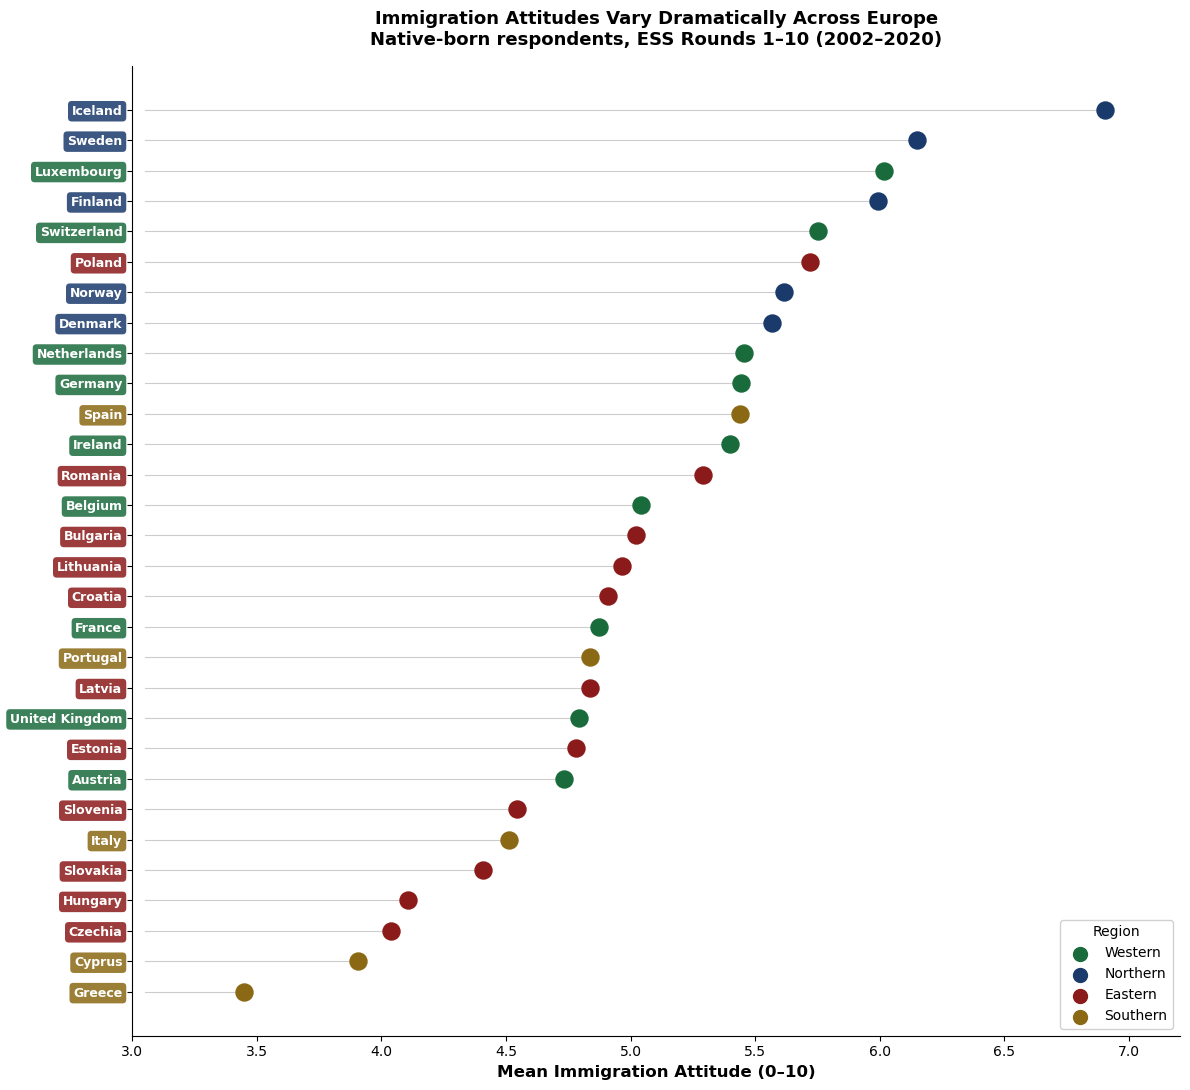

Fig 1 done


In [3]:
fig, ax = plt.subplots(figsize=(12, 11))

min_val = 3.0
max_val = country_means['immig_attitude'].max()

for i, row in country_means.iterrows():
    color = region_colors.get(row['region'], 'grey')
    ax.scatter(row['immig_attitude'], i, color=color, s=150, zorder=3)
    ax.plot([row['immig_attitude'] - 0.02, min_val + 0.05], [i, i],
            color='#cccccc', linewidth=0.8, zorder=1)

for region, color in region_colors.items():
    ax.scatter([], [], color=color, s=100, label=region)
ax.legend(title='Region', fontsize=10, title_fontsize=10,
          loc='lower right', framealpha=0.9)

ax.set_yticks(range(len(country_means)))
ax.set_yticklabels(country_means['country_name'].tolist(), fontsize=9)

for tick, (_, row) in zip(ax.get_yticklabels(), country_means.iterrows()):
    color = region_colors.get(row['region'], 'grey')
    tick.set_color('white')
    tick.set_fontweight('bold')
    tick.set_bbox(dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.85, edgecolor='none'))

ax.set_xlabel('Mean Immigration Attitude (0–10)', fontsize=12, fontweight='bold')
ax.set_title('Immigration Attitudes Vary Dramatically Across Europe\n'
             'Native-born respondents, ESS Rounds 1–10 (2002–2020)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(min_val, max_val + 0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig1_dotplot.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Fig 1 done")

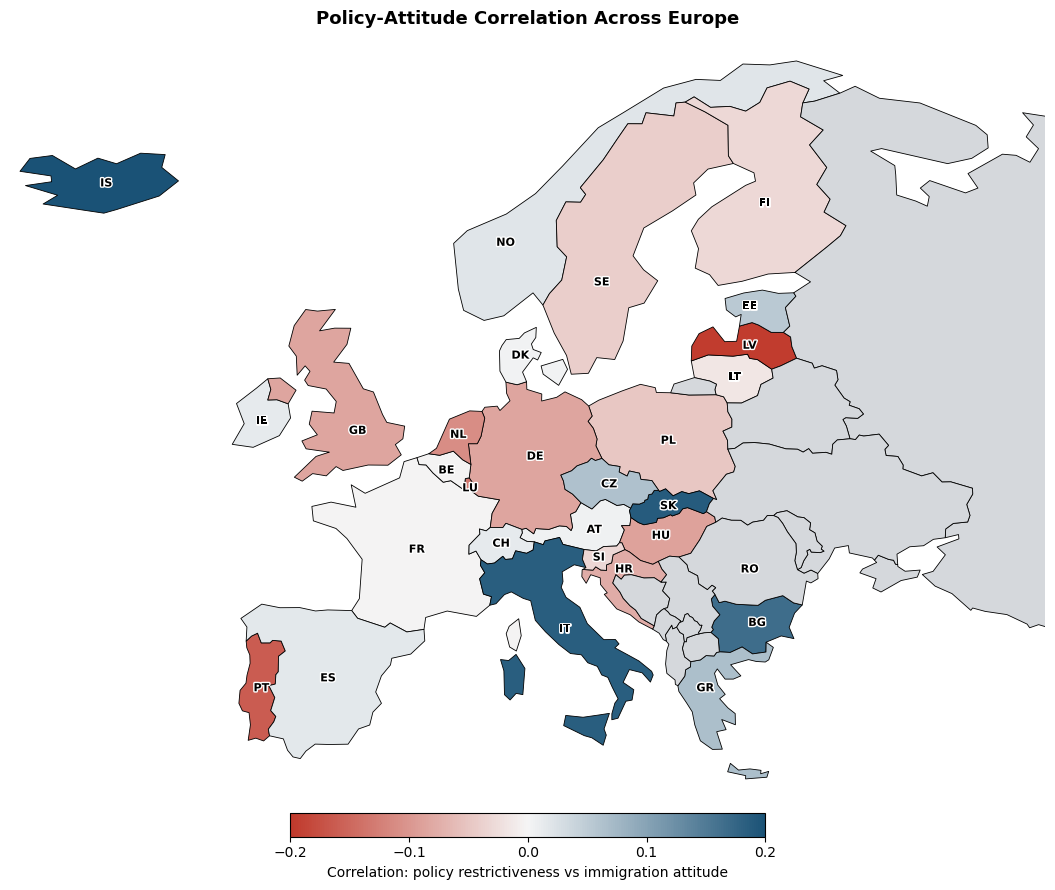

Fig 2 done


In [4]:
label_overrides = {
    'FR':(2.5,46.5),'CH':(8.2,46.8),'LU':(6.1,49.6),'BE':(4.5,50.5),
    'AT':(14.5,47.5),'SI':(14.8,46.1),'DK':(9.5,56.3),'NL':(5.3,52.3),
    'DE':(10.5,51.2),'CZ':(15.5,49.8),'SK':(19.5,48.7),'HU':(19.0,47.2),
    'HR':(16.5,45.5),'LT':(24.0,55.2),'LV':(25.0,56.8),'EE':(25.0,58.8),
    'GB':(-1.5,52.5),'IE':(-8.0,53.0),'PT':(-8.0,39.5),'ES':(-3.5,40.0),
    'IT':(12.5,42.5),'GR':(22.0,39.5),'BG':(25.5,42.8),'RO':(25.0,45.5),
    'PL':(19.5,52.0),'SE':(15.0,60.0),'NO':(8.5,62.0),'FI':(26.0,64.0),
    'IS':(-18.5,65.0)
}

custom_cmap = LinearSegmentedColormap.from_list('custom', ['#C0392B', '#F5F5F5', '#1A5276'])

try:
    world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
    europe = world[world['CONTINENT'] == 'Europe'].copy()
    europe = europe.merge(corr_df[['country_name', 'r', 'cntry']],
                         left_on='NAME', right_on='country_name', how='left')

    fig, ax = plt.subplots(figsize=(14, 9))
    europe.plot(column='r', cmap=custom_cmap, ax=ax, vmin=-0.2, vmax=0.2,
               edgecolor='black', linewidth=0.6,
               missing_kwds={'color':'#D5D8DC', 'edgecolor':'black', 'linewidth':0.6})

    for _, row in europe.iterrows():
        if pd.notna(row.get('cntry')) and row.geometry is not None:
            cntry = row['cntry']
            x, y = label_overrides.get(cntry, (row.geometry.centroid.x, row.geometry.centroid.y))
            if -25 <= x <= 45 and 34 <= y <= 72:
                ax.annotate(cntry, xy=(x, y), ha='center', va='center',
                           fontsize=8, fontweight='bold', color='black',
                           path_effects=[pe.withStroke(linewidth=2, foreground='white')])

    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=-0.2, vmax=0.2))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.02, shrink=0.6)
    cbar.set_label('Correlation: policy restrictiveness vs immigration attitude', fontsize=10)
    cbar.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])

    ax.set_xlim(-25, 45)
    ax.set_ylim(34, 72)
    ax.set_title('Policy-Attitude Correlation Across Europe',
                fontsize=13, fontweight='bold', pad=15)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig2_europe_map.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Fig 2 done")
except Exception as e:
    print(f"Map error: {e}")

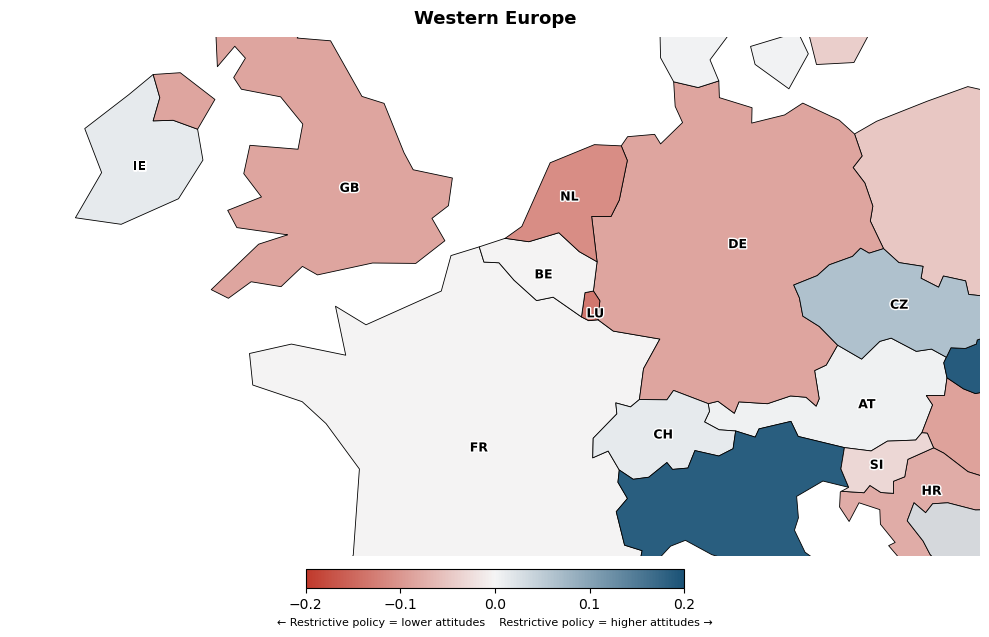

Western done


In [5]:
try:
    world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
    europe = world[world['CONTINENT'] == 'Europe'].copy()
    europe = europe.merge(corr_df[['country_name', 'r', 'cntry']],
                         left_on='NAME', right_on='country_name', how='left')

    fig, ax = plt.subplots(figsize=(10, 7))
    europe.plot(column='r', cmap=custom_cmap, ax=ax, vmin=-0.2, vmax=0.2,
               edgecolor='black', linewidth=0.6,
               missing_kwds={'color':'#D5D8DC', 'edgecolor':'black', 'linewidth':0.6})
    for _, row in europe.iterrows():
        if pd.notna(row.get('cntry')) and row.geometry is not None:
            cntry = row['cntry']
            x, y = label_overrides.get(cntry, (row.geometry.centroid.x, row.geometry.centroid.y))
            if -12 <= x <= 18 and 44 <= y <= 56:
                ax.annotate(cntry, xy=(x, y), ha='center', va='center',
                           fontsize=9, fontweight='bold', color='black',
                           path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=-0.2, vmax=0.2))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.02, shrink=0.7)
    cbar.set_label('← Restrictive policy = lower attitudes    Restrictive policy = higher attitudes →', fontsize=8)
    cbar.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])
    ax.set_xlim(-12, 18)
    ax.set_ylim(44, 56)
    ax.set_title('Western Europe', fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_map_western.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Western done")
except Exception as e:
    print(f"Error: {e}")

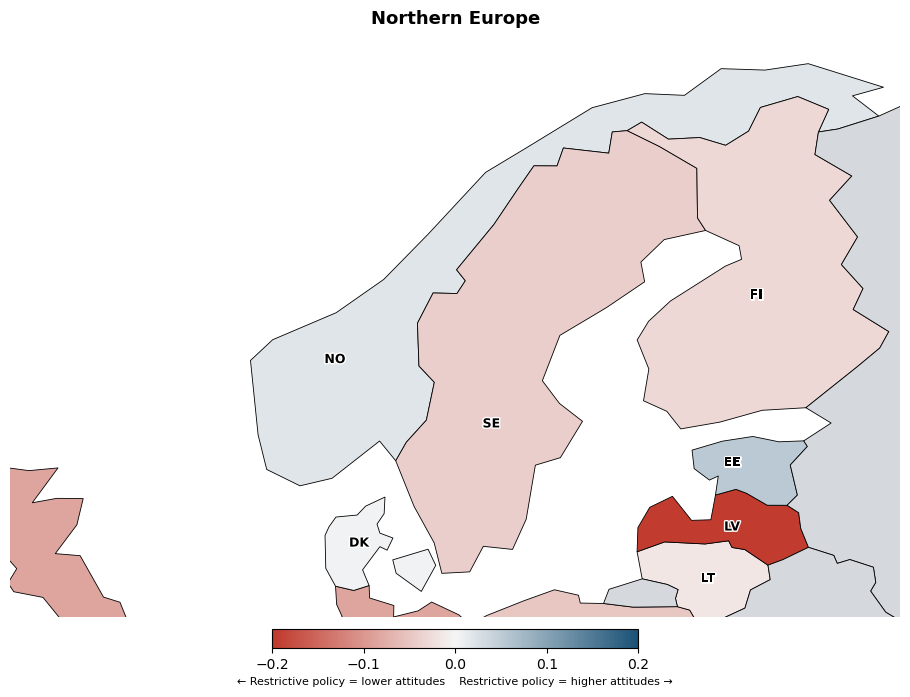

Northern done


In [6]:
try:
    fig, ax = plt.subplots(figsize=(10, 7))
    europe.plot(column='r', cmap=custom_cmap, ax=ax, vmin=-0.2, vmax=0.2,
               edgecolor='black', linewidth=0.6,
               missing_kwds={'color':'#D5D8DC', 'edgecolor':'black', 'linewidth':0.6})
    for _, row in europe.iterrows():
        if pd.notna(row.get('cntry')) and row.geometry is not None:
            cntry = row['cntry']
            x, y = label_overrides.get(cntry, (row.geometry.centroid.x, row.geometry.centroid.y))
            if -5 <= x <= 32 and 54 <= y <= 72:
                ax.annotate(cntry, xy=(x, y), ha='center', va='center',
                           fontsize=9, fontweight='bold', color='black',
                           path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=-0.2, vmax=0.2))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.02, shrink=0.7)
    cbar.set_label('← Restrictive policy = lower attitudes    Restrictive policy = higher attitudes →', fontsize=8)
    cbar.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])
    ax.set_xlim(-5, 32)
    ax.set_ylim(54, 72)
    ax.set_title('Northern Europe', fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_map_northern.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Northern done")
except Exception as e:
    print(f"Error: {e}")

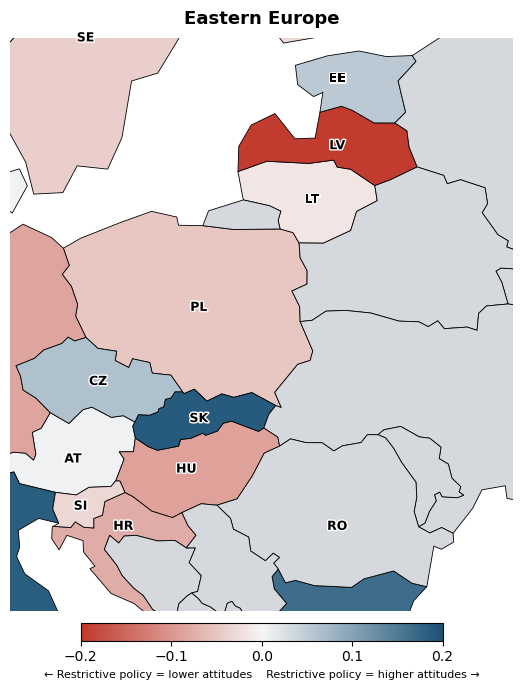

Eastern done


In [7]:
try:
    fig, ax = plt.subplots(figsize=(10, 7))
    europe.plot(column='r', cmap=custom_cmap, ax=ax, vmin=-0.2, vmax=0.2,
               edgecolor='black', linewidth=0.6,
               missing_kwds={'color':'#D5D8DC', 'edgecolor':'black', 'linewidth':0.6})
    for _, row in europe.iterrows():
        if pd.notna(row.get('cntry')) and row.geometry is not None:
            cntry = row['cntry']
            x, y = label_overrides.get(cntry, (row.geometry.centroid.x, row.geometry.centroid.y))
            if 12 <= x <= 32 and 43 <= y <= 60:
                ax.annotate(cntry, xy=(x, y), ha='center', va='center',
                           fontsize=9, fontweight='bold', color='black',
                           path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=-0.2, vmax=0.2))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.02, shrink=0.7)
    cbar.set_label('← Restrictive policy = lower attitudes    Restrictive policy = higher attitudes →', fontsize=8)
    cbar.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])
    ax.set_xlim(12, 32)
    ax.set_ylim(43, 60)
    ax.set_title('Eastern Europe', fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_map_eastern.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Eastern done")
except Exception as e:
    print(f"Error: {e}")

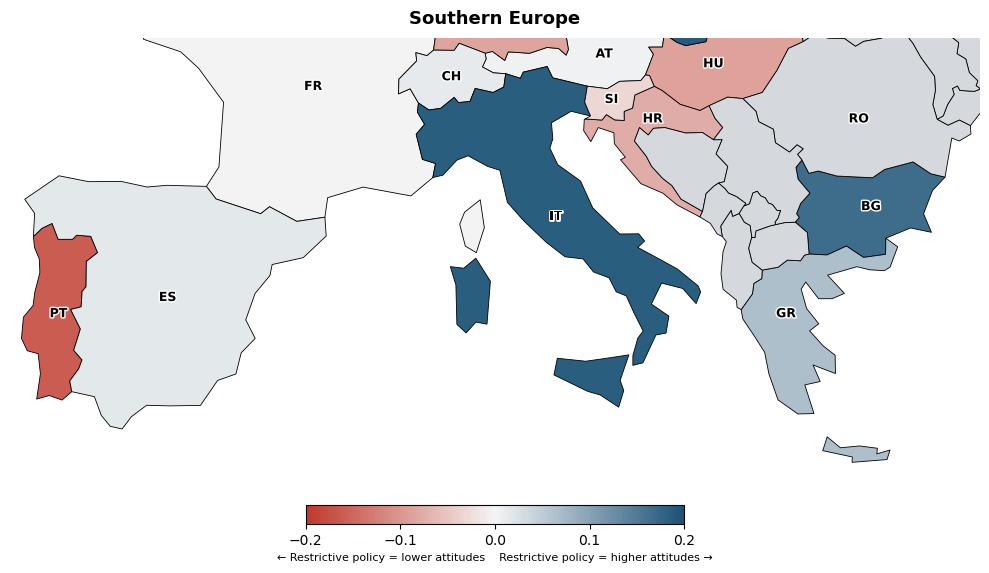

Southern done


In [8]:
try:
    fig, ax = plt.subplots(figsize=(10, 7))
    europe.plot(column='r', cmap=custom_cmap, ax=ax, vmin=-0.2, vmax=0.2,
               edgecolor='black', linewidth=0.6,
               missing_kwds={'color':'#D5D8DC', 'edgecolor':'black', 'linewidth':0.6})
    for _, row in europe.iterrows():
        if pd.notna(row.get('cntry')) and row.geometry is not None:
            cntry = row['cntry']
            x, y = label_overrides.get(cntry, (row.geometry.centroid.x, row.geometry.centroid.y))
            if -10 <= x <= 30 and 34 <= y <= 48:
                ax.annotate(cntry, xy=(x, y), ha='center', va='center',
                           fontsize=9, fontweight='bold', color='black',
                           path_effects=[pe.withStroke(linewidth=2, foreground='white')])
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=-0.2, vmax=0.2))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.02, shrink=0.7)
    cbar.set_label('← Restrictive policy = lower attitudes    Restrictive policy = higher attitudes →', fontsize=8)
    cbar.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])
    ax.set_xlim(-10, 30)
    ax.set_ylim(34, 48)
    ax.set_title('Southern Europe', fontsize=13, fontweight='bold', pad=10)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig3_map_southern.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Southern done")
except Exception as e:
    print(f"Error: {e}")

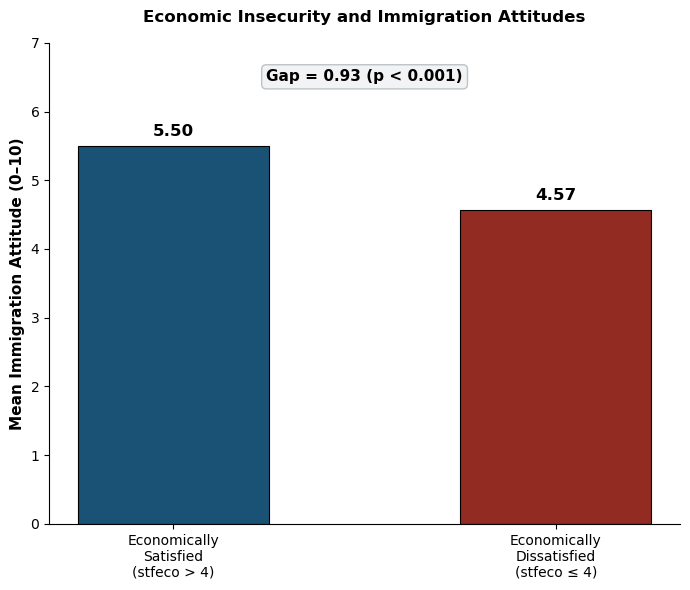

Fig 4 done


In [9]:
means = [
    ess_merged[ess_merged['econ_dissatisfied'] == 0]['immig_attitude'].mean(),
    ess_merged[ess_merged['econ_dissatisfied'] == 1]['immig_attitude'].mean()
]
gap = means[0] - means[1]

fig, ax = plt.subplots(figsize=(7, 6))
groups = ['Economically\nSatisfied\n(stfeco > 4)', 'Economically\nDissatisfied\n(stfeco ≤ 4)']
colors = ['#1A5276', '#922B21']
bars = ax.bar(groups, means, color=colors, width=0.5, edgecolor='black', linewidth=0.8)

ax.set_ylim(0, 7)
ax.set_ylabel('Mean Immigration Attitude (0–10)', fontsize=11, fontweight='bold')
ax.set_title('Economic Insecurity and Immigration Attitudes',
            fontsize=12, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, mean + 0.1,
            f'{mean:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.text(0.5, 0.92, f'Gap = {gap:.2f} (p < 0.001)',
        transform=ax.transAxes, ha='center', fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#F2F3F4', edgecolor='#BDC3C7'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig4_econ_barchart.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Fig 4 done")

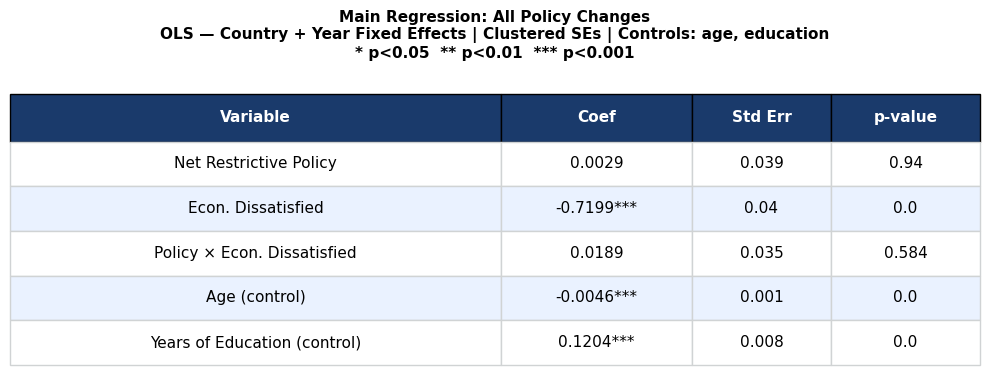

Fig 5 done


In [10]:
reg_results = pd.read_csv('regression_results.csv')
reg_results = reg_results.rename(columns={'Unnamed: 0': 'variable'})

name_map = {
    'net_restrict_std': 'Net Restrictive Policy',
    'econ_dissatisfied': 'Econ. Dissatisfied',
    'net_restrict_std:econ_dissatisfied': 'Policy × Econ. Dissatisfied',
    'agea': 'Age (control)',
    'eduyrs': 'Years of Education (control)'
}
reg_results['variable'] = reg_results['variable'].map(name_map).fillna(reg_results['variable'])

# Add significance stars based on p-value
def add_stars(row):
    p = float(row['P>|z|'])
    coef = row['coef']
    if p < 0.001:
        return f"{coef}***"
    elif p < 0.01:
        return f"{coef}**"
    elif p < 0.05:
        return f"{coef}*"
    else:
        return f"{coef}"

reg_results['coef_stars'] = reg_results.apply(add_stars, axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=reg_results[['variable', 'coef_stars', 'std err', 'P>|z|']].values,
    colLabels=['Variable', 'Coef', 'Std Err', 'p-value'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0.05, 1, 0.9]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width([0, 1, 2, 3])

for j in range(4):
    table[0, j].set_facecolor('#1A3A6B')
    table[0, j].set_text_props(color='white', fontweight='bold')
    table[0, j].set_height(0.15)

for i in range(1, len(reg_results) + 1):
    for j in range(4):
        if i % 2 == 0:
            table[i, j].set_facecolor('#EAF2FF')
        else:
            table[i, j].set_facecolor('white')
        table[i, j].set_edgecolor('#D0D3D4')
        table[i, j].set_height(0.14)

ax.set_title('Main Regression: All Policy Changes\n'
            'OLS — Country + Year Fixed Effects | Clustered SEs | Controls: age, education\n'
            '* p<0.05  ** p<0.01  *** p<0.001',
            fontsize=11, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig5_regression_table.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Fig 5 done")

In [11]:
# Load DEMIG and compute yearly net restrictiveness across all countries
policy_raw = pd.read_csv('migration_policy.xls', sep='\t')
policy_raw['Restrictiveness'] = policy_raw['Restrictiveness'].str.strip().str.lower()
policy_raw = policy_raw[policy_raw['Restrictiveness'].isin(['more restrictive', 'less restrictive'])].copy()
policy_raw['restrict_score'] = policy_raw['Restrictiveness'].map({'more restrictive': 1, 'less restrictive': -1})
policy_raw['Magnitude'] = policy_raw['Magnitude'].str.strip().str.lower()
policy_raw['Year'] = pd.to_numeric(policy_raw['Year'], errors='coerce')
policy_raw = policy_raw.dropna(subset=['Year'])
policy_raw['Year'] = policy_raw['Year'].astype(int)

# Filter to 2000-2020
policy_raw = policy_raw[policy_raw['Year'].between(2000, 2020)]

yearly_all = policy_raw.groupby('Year')['restrict_score'].sum().reset_index()
yearly_major = policy_raw[policy_raw['Magnitude'] == 'major change'].groupby('Year')['restrict_score'].sum().reset_index()
yearly_nonmajor = policy_raw[policy_raw['Magnitude'] != 'major change'].groupby('Year')['restrict_score'].sum().reset_index()

print("Yearly data ready")
print(yearly_all.tail(5))

Yearly data ready
    Year  restrict_score
16  2016             -14
17  2017             -84
18  2018            -110
19  2019             -25
20  2020              -5


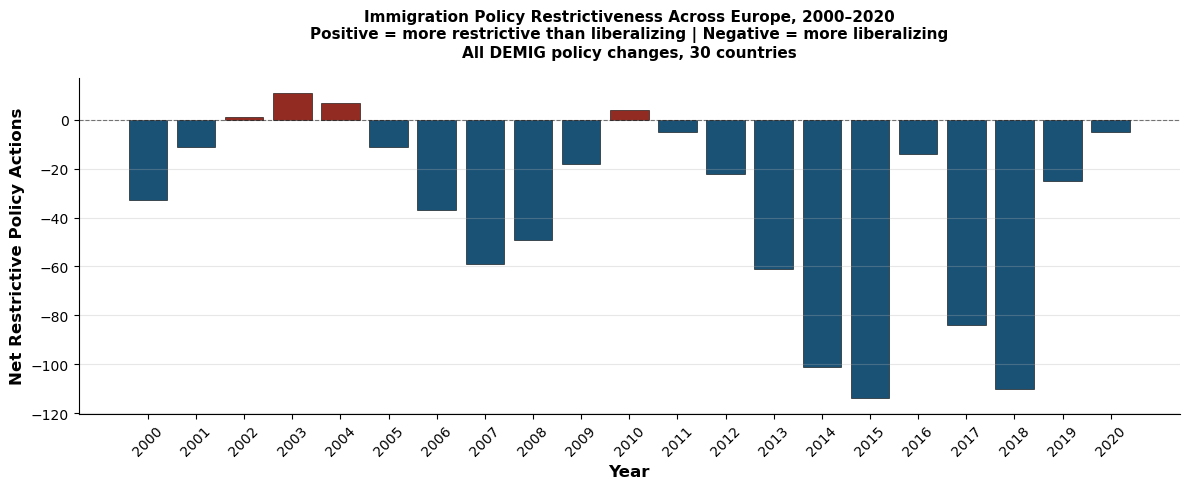

Fig 7 done


In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#922B21' if v > 0 else '#1A5276' for v in yearly_all['restrict_score']]
ax.bar(yearly_all['Year'], yearly_all['restrict_score'],
       color=colors, edgecolor='black', linewidth=0.4, width=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Net Restrictive Policy Actions', fontsize=12, fontweight='bold')
ax.set_title('Immigration Policy Restrictiveness Across Europe, 2000–2020\n'
             'Positive = more restrictive than liberalizing | Negative = more liberalizing\n'
             'All DEMIG policy changes, 30 countries',
             fontsize=11, fontweight='bold', pad=15)
ax.set_xticks(yearly_all['Year'])
ax.set_xticklabels(yearly_all['Year'], rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig7_all_policy_yearly.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Fig 7 done")

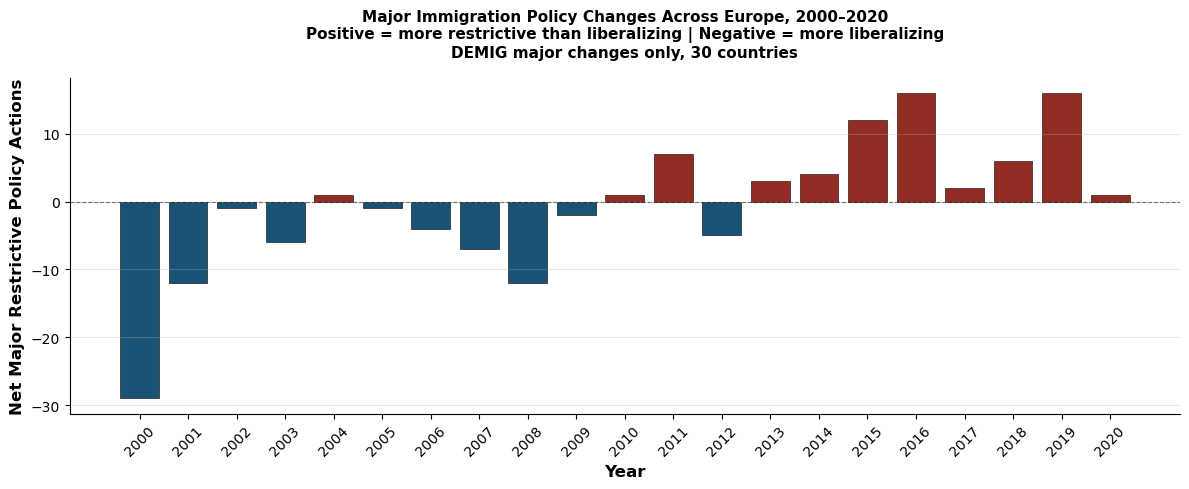

Fig 8 done


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#922B21' if v > 0 else '#1A5276' for v in yearly_major['restrict_score']]
ax.bar(yearly_major['Year'], yearly_major['restrict_score'],
       color=colors, edgecolor='black', linewidth=0.4, width=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Net Major Restrictive Policy Actions', fontsize=12, fontweight='bold')
ax.set_title('Major Immigration Policy Changes Across Europe, 2000–2020\n'
             'Positive = more restrictive than liberalizing | Negative = more liberalizing\n'
             'DEMIG major changes only, 30 countries',
             fontsize=11, fontweight='bold', pad=15)
ax.set_xticks(yearly_major['Year'])
ax.set_xticklabels(yearly_major['Year'], rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig8_major_policy_yearly.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Fig 8 done")

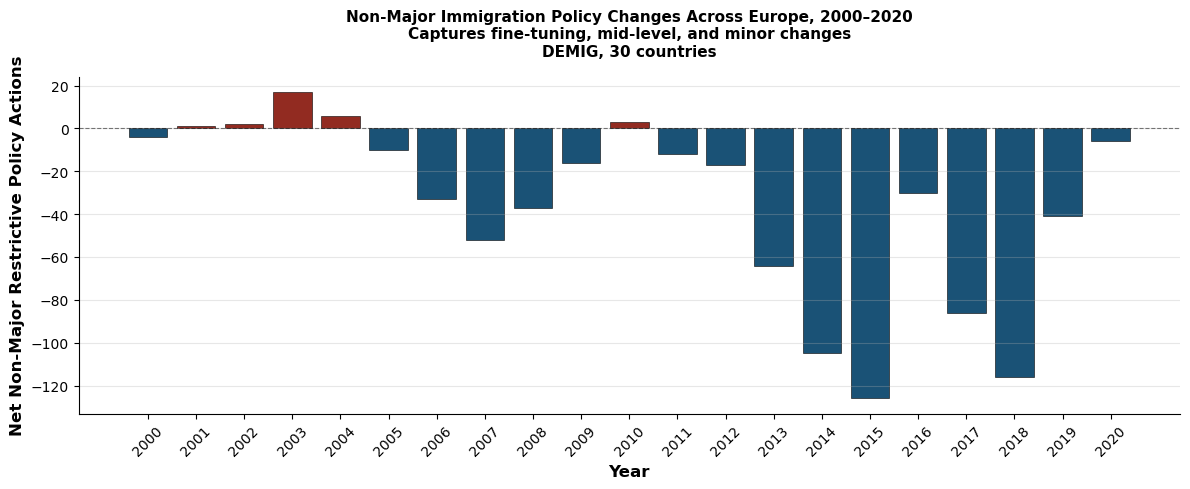

Fig 9 done


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#922B21' if v > 0 else '#1A5276' for v in yearly_nonmajor['restrict_score']]
ax.bar(yearly_nonmajor['Year'], yearly_nonmajor['restrict_score'],
       color=colors, edgecolor='black', linewidth=0.4, width=0.8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Net Non-Major Restrictive Policy Actions', fontsize=12, fontweight='bold')
ax.set_title('Non-Major Immigration Policy Changes Across Europe, 2000–2020\n'
             'Captures fine-tuning, mid-level, and minor changes\n'
             'DEMIG, 30 countries',
             fontsize=11, fontweight='bold', pad=15)
ax.set_xticks(yearly_nonmajor['Year'])
ax.set_xticklabels(yearly_nonmajor['Year'], rotation=45)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig9_nonmajor_policy_yearly.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Fig 9 done")

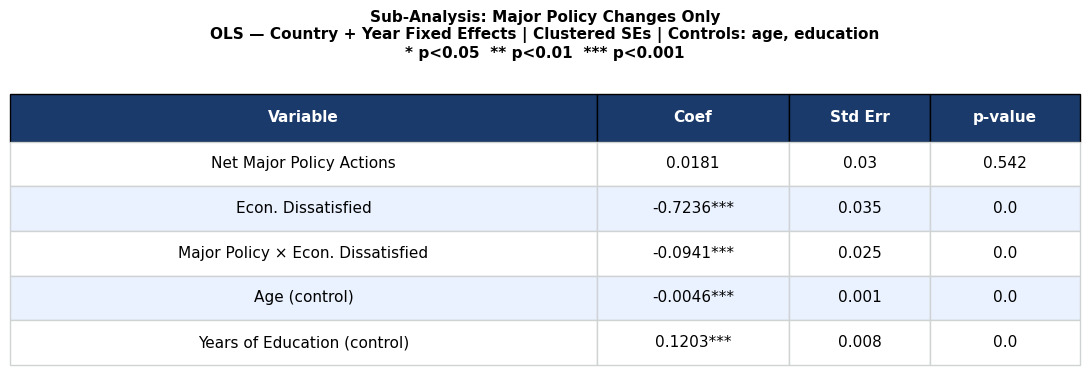

Fig 10 done


In [15]:
reg_major = pd.read_csv('regression_results_major.csv')
reg_major = reg_major.rename(columns={'Unnamed: 0': 'variable'})

name_map_major = {
    'net_major_std': 'Net Major Policy Actions',
    'econ_dissatisfied': 'Econ. Dissatisfied',
    'net_major_std:econ_dissatisfied': 'Major Policy × Econ. Dissatisfied',
    'agea': 'Age (control)',
    'eduyrs': 'Years of Education (control)'
}
reg_major['variable'] = reg_major['variable'].map(name_map_major).fillna(reg_major['variable'])

# Add significance stars based on p-value
def add_stars(row):
    p = float(row['P>|z|'])
    coef = row['coef']
    if p < 0.001:
        return f"{coef}***"
    elif p < 0.01:
        return f"{coef}**"
    elif p < 0.05:
        return f"{coef}*"
    else:
        return f"{coef}"

reg_major['coef_stars'] = reg_major.apply(add_stars, axis=1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.axis('off')

table = ax.table(
    cellText=reg_major[['variable', 'coef_stars', 'std err', 'P>|z|']].values,
    colLabels=['Variable', 'Coef', 'Std Err', 'p-value'],
    cellLoc='center',
    loc='center',
    bbox=[0, 0.05, 1, 0.9]
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.auto_set_column_width([0, 1, 2, 3])

for j in range(4):
    table[0, j].set_facecolor('#1A3A6B')
    table[0, j].set_text_props(color='white', fontweight='bold')
    table[0, j].set_height(0.15)

for i in range(1, len(reg_major) + 1):
    for j in range(4):
        if i % 2 == 0:
            table[i, j].set_facecolor('#EAF2FF')
        else:
            table[i, j].set_facecolor('white')
        table[i, j].set_edgecolor('#D0D3D4')
        table[i, j].set_height(0.14)

ax.set_title('Sub-Analysis: Major Policy Changes Only\n'
            'OLS — Country + Year Fixed Effects | Clustered SEs | Controls: age, education\n'
            '* p<0.05  ** p<0.01  *** p<0.001',
            fontsize=11, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig10_major_regression_table.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Fig 10 done")

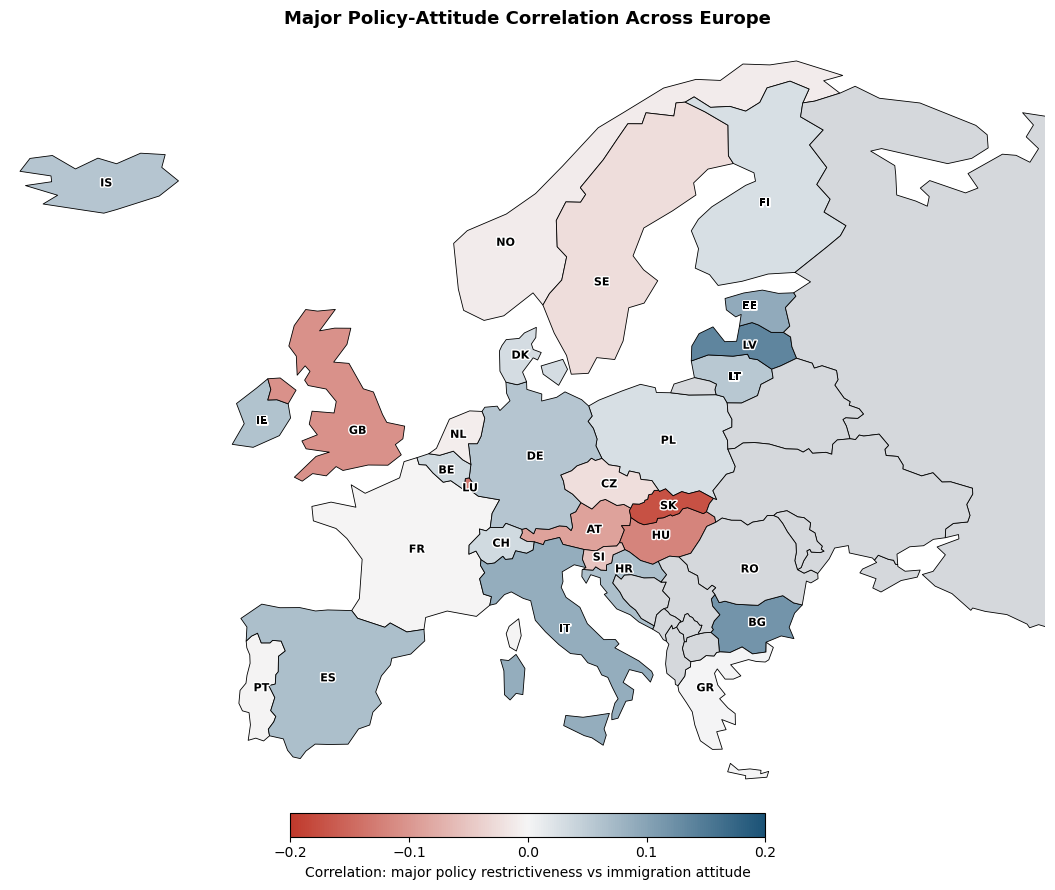

Fig 11 done


In [16]:
corr_major_results = []
for country in ess_merged['cntry'].unique():
    subset = ess_merged[ess_merged['cntry'] == country].dropna(
        subset=['immig_attitude', 'net_major_score']
    )
    if len(subset) >= 5:
        r, p = stats.pearsonr(subset['net_major_score'], subset['immig_attitude'])
        corr_major_results.append({
            'cntry': country,
            'r_major': round(r, 3),
            'p_major': round(p, 3)
        })

corr_major_df = pd.DataFrame(corr_major_results)
if 'RO' not in corr_major_df['cntry'].values:
    corr_major_df = pd.concat([
        corr_major_df,
        pd.DataFrame([{'cntry': 'RO', 'r_major': 0.0, 'p_major': 1.0}])
    ], ignore_index=True)
corr_major_df['country_name'] = corr_major_df['cntry'].map(cntry_to_name)

try:
    world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")
    europe = world[world['CONTINENT'] == 'Europe'].copy()
    europe = europe.merge(corr_major_df[['country_name', 'r_major', 'cntry']],
                         left_on='NAME', right_on='country_name', how='left')

    fig, ax = plt.subplots(figsize=(14, 9))
    europe.plot(column='r_major', cmap=custom_cmap, ax=ax, vmin=-0.2, vmax=0.2,
               edgecolor='black', linewidth=0.6,
               missing_kwds={'color':'#D5D8DC', 'edgecolor':'black', 'linewidth':0.6})

    for _, row in europe.iterrows():
        if pd.notna(row.get('cntry')) and row.geometry is not None:
            cntry = row['cntry']
            x, y = label_overrides.get(cntry, (row.geometry.centroid.x, row.geometry.centroid.y))
            if -25 <= x <= 45 and 34 <= y <= 72:
                ax.annotate(cntry, xy=(x, y), ha='center', va='center',
                           fontsize=8, fontweight='bold', color='black',
                           path_effects=[pe.withStroke(linewidth=2, foreground='white')])

    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=plt.Normalize(vmin=-0.2, vmax=0.2))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.03, pad=0.02, shrink=0.6)
    cbar.set_label('Correlation: major policy restrictiveness vs immigration attitude', fontsize=10)
    cbar.set_ticks([-0.2, -0.1, 0, 0.1, 0.2])

    ax.set_xlim(-25, 45)
    ax.set_ylim(34, 72)
    ax.set_title('Major Policy-Attitude Correlation Across Europe',
                fontsize=13, fontweight='bold', pad=15)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig11_major_europe_map.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("Fig 11 done")
except Exception as e:
    print(f"Map error: {e}")

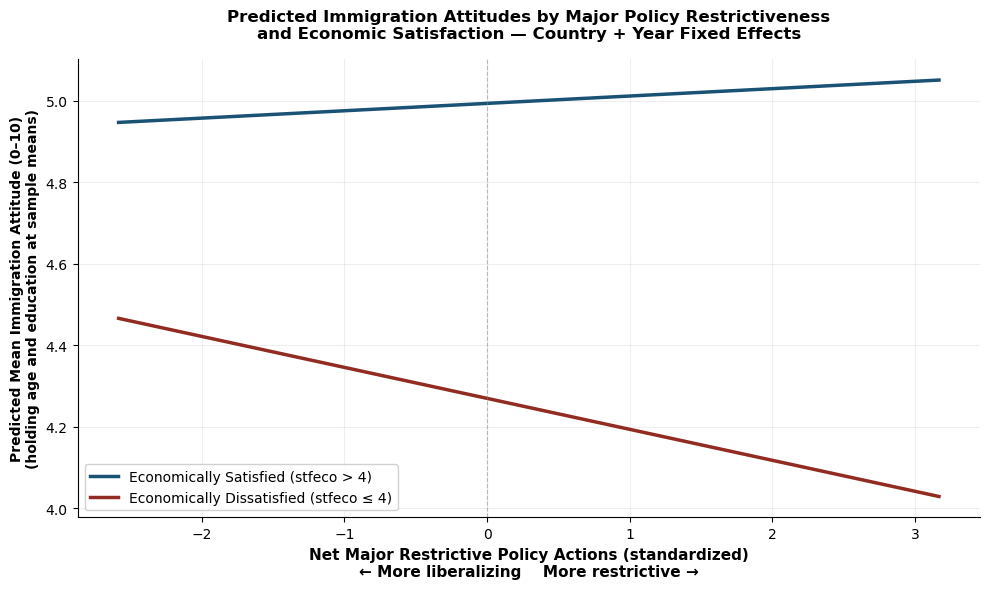

Fig 12 done


In [17]:
reg_df_major_plot = ess_merged.dropna(
    subset=['immig_attitude', 'net_major_score', 'agea', 'eduyrs', 'stfeco']
).copy()
reg_df_major_plot['net_major_std'] = (
    (reg_df_major_plot['net_major_score'] - reg_df_major_plot['net_major_score'].mean()) /
    reg_df_major_plot['net_major_score'].std()
)

m_major_plot = smf.ols(
    'immig_attitude ~ net_major_std * econ_dissatisfied + agea + eduyrs + C(cntry) + C(year)',
    data=reg_df_major_plot
).fit(cov_type='cluster', cov_kwds={'groups': reg_df_major_plot['cntry']})

restrict_vals = np.linspace(reg_df_major_plot['net_major_std'].min(),
                            reg_df_major_plot['net_major_std'].max(), 100)
mean_age = reg_df_major_plot['agea'].mean()
mean_eduyrs = reg_df_major_plot['eduyrs'].mean()

pred_satisfied = (m_major_plot.params['Intercept'] +
                 m_major_plot.params['net_major_std'] * restrict_vals +
                 m_major_plot.params['agea'] * mean_age +
                 m_major_plot.params['eduyrs'] * mean_eduyrs)

pred_dissatisfied = (m_major_plot.params['Intercept'] +
                    m_major_plot.params['net_major_std'] * restrict_vals +
                    m_major_plot.params['econ_dissatisfied'] +
                    m_major_plot.params['net_major_std:econ_dissatisfied'] * restrict_vals +
                    m_major_plot.params['agea'] * mean_age +
                    m_major_plot.params['eduyrs'] * mean_eduyrs)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(restrict_vals, pred_satisfied, color='#1A5276', linewidth=2.5,
        label='Economically Satisfied (stfeco > 4)')
ax.plot(restrict_vals, pred_dissatisfied, color='#922B21', linewidth=2.5,
        label='Economically Dissatisfied (stfeco ≤ 4)')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xlabel('Net Major Restrictive Policy Actions (standardized)\n← More liberalizing    More restrictive →',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Mean Immigration Attitude (0–10)\n(holding age and education at sample means)',
             fontsize=10, fontweight='bold')
ax.set_title('Predicted Immigration Attitudes by Major Policy Restrictiveness\nand Economic Satisfaction — Country + Year Fixed Effects',
            fontsize=12, fontweight='bold', pad=15)
ax.legend(fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig12_major_interaction.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Fig 12 done")

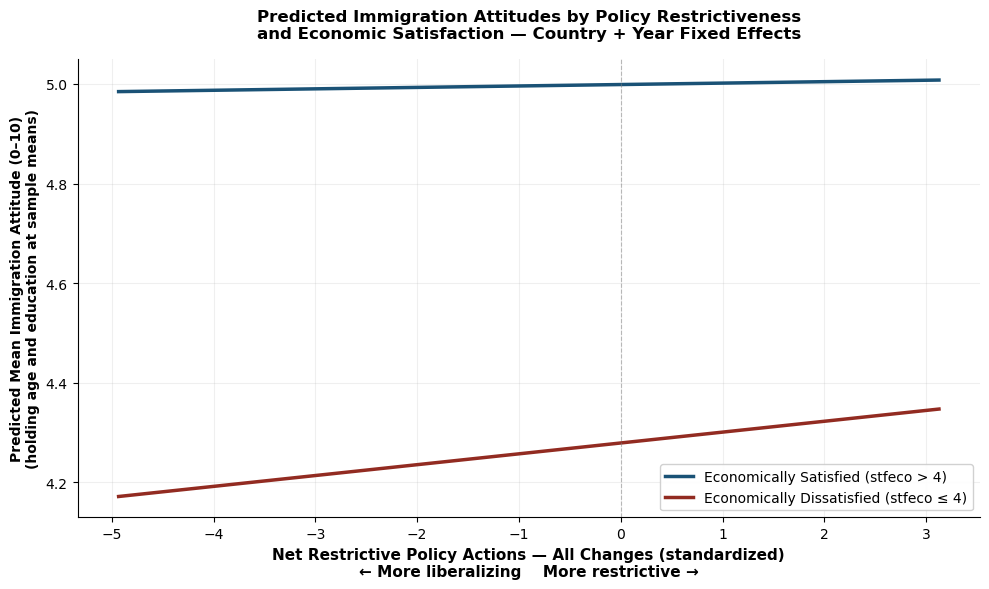

Fig 13 done


In [18]:
reg_df_all_plot = ess_merged.dropna(
    subset=['immig_attitude', 'net_restrict_score', 'agea', 'eduyrs', 'stfeco']
).copy()
reg_df_all_plot['net_restrict_std'] = (
    (reg_df_all_plot['net_restrict_score'] - reg_df_all_plot['net_restrict_score'].mean()) /
    reg_df_all_plot['net_restrict_score'].std()
)

m_all_plot = smf.ols(
    'immig_attitude ~ net_restrict_std * econ_dissatisfied + agea + eduyrs + C(cntry) + C(year)',
    data=reg_df_all_plot
).fit(cov_type='cluster', cov_kwds={'groups': reg_df_all_plot['cntry']})

restrict_vals_all = np.linspace(reg_df_all_plot['net_restrict_std'].min(),
                                reg_df_all_plot['net_restrict_std'].max(), 100)
mean_age = reg_df_all_plot['agea'].mean()
mean_eduyrs = reg_df_all_plot['eduyrs'].mean()

pred_satisfied_all = (m_all_plot.params['Intercept'] +
                     m_all_plot.params['net_restrict_std'] * restrict_vals_all +
                     m_all_plot.params['agea'] * mean_age +
                     m_all_plot.params['eduyrs'] * mean_eduyrs)

pred_dissatisfied_all = (m_all_plot.params['Intercept'] +
                        m_all_plot.params['net_restrict_std'] * restrict_vals_all +
                        m_all_plot.params['econ_dissatisfied'] +
                        m_all_plot.params['net_restrict_std:econ_dissatisfied'] * restrict_vals_all +
                        m_all_plot.params['agea'] * mean_age +
                        m_all_plot.params['eduyrs'] * mean_eduyrs)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(restrict_vals_all, pred_satisfied_all, color='#1A5276', linewidth=2.5,
        label='Economically Satisfied (stfeco > 4)')
ax.plot(restrict_vals_all, pred_dissatisfied_all, color='#922B21', linewidth=2.5,
        label='Economically Dissatisfied (stfeco ≤ 4)')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xlabel('Net Restrictive Policy Actions — All Changes (standardized)\n← More liberalizing    More restrictive →',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Mean Immigration Attitude (0–10)\n(holding age and education at sample means)',
             fontsize=10, fontweight='bold')
ax.set_title('Predicted Immigration Attitudes by Policy Restrictiveness\nand Economic Satisfaction — Country + Year Fixed Effects',
            fontsize=12, fontweight='bold', pad=15)
ax.legend(fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig13_all_interaction.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Fig 13 done")